# DBSCAN Project

Real-world data is rarely polite.

It bends. It breaks into strange shapes. It contains rare points, noisy behavior, crowded regions, quiet gaps, and patterns that refuse to sit inside neat circles.

DBSCAN is built for that kind of mess.

> What if the data itself decides how clusters should form?

This project is about teaching machines to discover natural groups in chaotic data without forcing every point to belong.

## 1. Problem Statement

Traditional clustering often expects clean structure. But real data is messy.

Fraud patterns may appear as strange pockets of activity. Customer behavior may form dense communities with rare unusual events around the edges. Geographic data may contain hotspots separated by empty space. Network intrusions may look like isolated bursts away from normal traffic.

The problem is not only grouping.

The problem is knowing when something should not belong to any group at all.

## 2. Why KMeans Sometimes Fails

KMeans is powerful, but it has a habit: it wants to assign every point to a cluster.

Even an outlier gets a cluster. Even a strange point in empty space gets pulled into the nearest center.

That is like forcing every person at a chaotic outdoor festival into a fixed room, even if some people are standing alone far from every crowd.

KMeans also prefers round-ish clusters. When the real pattern bends into moons, rings, curves, or messy density regions, KMeans may cut through natural shapes.

## 3. What Makes DBSCAN Different?

DBSCAN is density-based.

It does not begin by asking how many clusters we want. It asks where the data is crowded.

Dense regions become clusters. Sparse regions become empty space. Isolated points become noise.

Think of a city map. A crowded downtown neighborhood feels like a natural community. A few isolated houses in the countryside do not need to be forced into downtown. DBSCAN respects that difference.

## 4. Dataset Overview

Dataset: synthetic noisy customer activity map created with scikit-learn `make_moons` plus random rare activity events.

Rows: 545 events

Features:

- `x_activity`: behavioral/location-like activity dimension
- `y_activity`: behavioral/location-like activity dimension
- `activity_intensity`: simulated activity strength
- `source`: dense activity or rare activity reference
- `reference_pattern`: hidden generator reference, not used for clustering

Business interpretation:

The dataset represents customer or user activity events where dense curved communities exist alongside rare unusual behavior. This is useful for demonstrating DBSCAN because the clusters are irregular and noisy.

## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from src.preprocessing.data_preprocessing import FEATURE_COLUMNS, save_raw_and_processed, scale_features
from src.clustering.dbscan_utils import cluster_counts, fit_dbscan, fit_kmeans
from src.anomaly_detection.noise_analysis import attach_cluster_labels, noise_summary
from src.evaluation.cluster_metrics import evaluate_dbscan_grid, k_distance_values
from src.dimensionality_reduction.pca_utils import run_pca
from src.experiments.parameter_sweep import run_parameter_sweep
from src.visualization.plots import (
    plot_cluster_scatter,
    plot_k_distance,
    plot_kmeans_vs_dbscan,
    plot_parameter_heatmap,
    plot_pca_clusters,
)

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 6. Load Dataset

In [2]:
raw_path = PROJECT_ROOT / "data/raw/noisy_customer_activity.csv"
processed_path = PROJECT_ROOT / "data/processed/noisy_customer_activity_processed.csv"

df = save_raw_and_processed(raw_path, processed_path)
df.head()

,customer_event_id,x_activity,y_activity,activity_intensity,source,reference_pattern
0,EVT-0001,0.830631,-0.428834,62.69,dense_activity,1
1,EVT-0002,0.750017,0.827265,76.11,dense_activity,0
2,EVT-0003,1.036274,-0.488866,66.78,dense_activity,1
3,EVT-0004,-0.287454,0.966723,55.84,dense_activity,0
4,EVT-0005,0.311954,1.102409,66.30,dense_activity,0


## 7. Initial Data Inspection

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nSource distribution:")
print(df["source"].value_counts())
df[FEATURE_COLUMNS + ["activity_intensity"]].describe().T

Shape: (545, 6)

Missing values:
customer_event_id     0
x_activity            0
y_activity            0
activity_intensity    0
source                0
reference_pattern     0
dtype: int64

Source distribution:
dense_activity    500
rare_activity      45
Name: source, dtype: int64


,count,mean,std,min,25%,50%,75%,max
x_activity,545.0,0.507258,0.897183,-1.504609,-0.051294,0.475005,1.104234,2.476932
y_activity,545.0,0.257146,0.526335,-0.980122,-0.215079,0.256008,0.715998,1.634180
activity_intensity,545.0,62.032092,16.273414,19.520000,50.490000,62.670000,72.980000,106.370000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_event_id   545 non-null    object 
 1   x_activity          545 non-null    float64
 2   y_activity          545 non-null    float64
 3   activity_intensity  545 non-null    float64
 4   source              545 non-null    object 
 5   reference_pattern   545 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 25.7+ KB


## 8. Exploratory Data Analysis

Before clustering, we look at the shape of the activity space. The structure is not round. It curves, and it contains rare scattered behavior. That is exactly where DBSCAN becomes interesting.

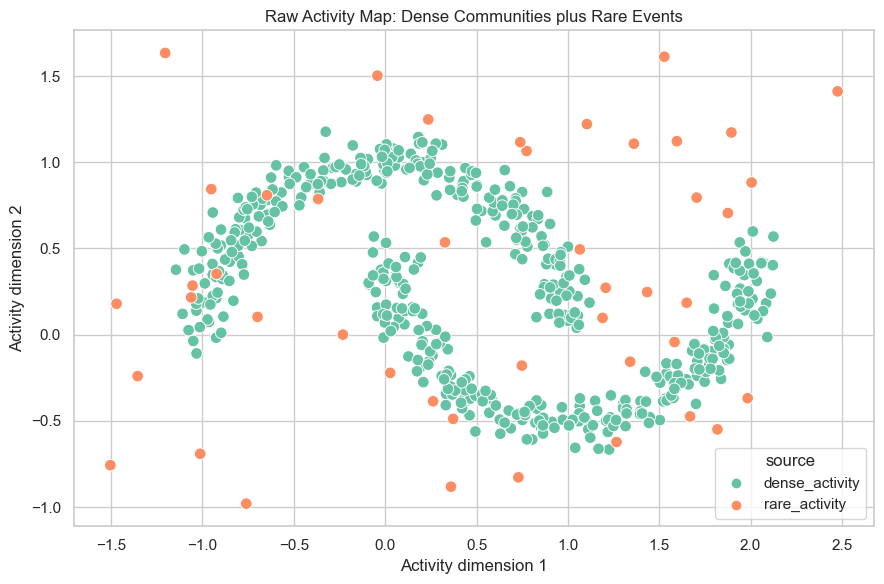

In [5]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="x_activity", y="y_activity", hue="source", s=70, edgecolor="white")
plt.title("Raw Activity Map: Dense Communities plus Rare Events")
plt.xlabel("Activity dimension 1")
plt.ylabel("Activity dimension 2")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "raw_activity_map.png", dpi=160, bbox_inches="tight")
plt.show()

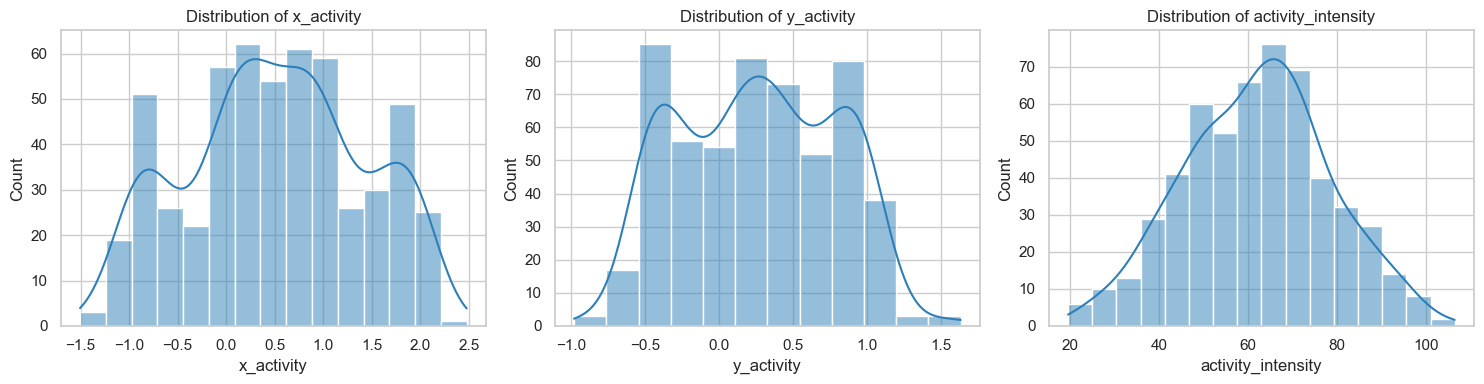

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["x_activity", "y_activity", "activity_intensity"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

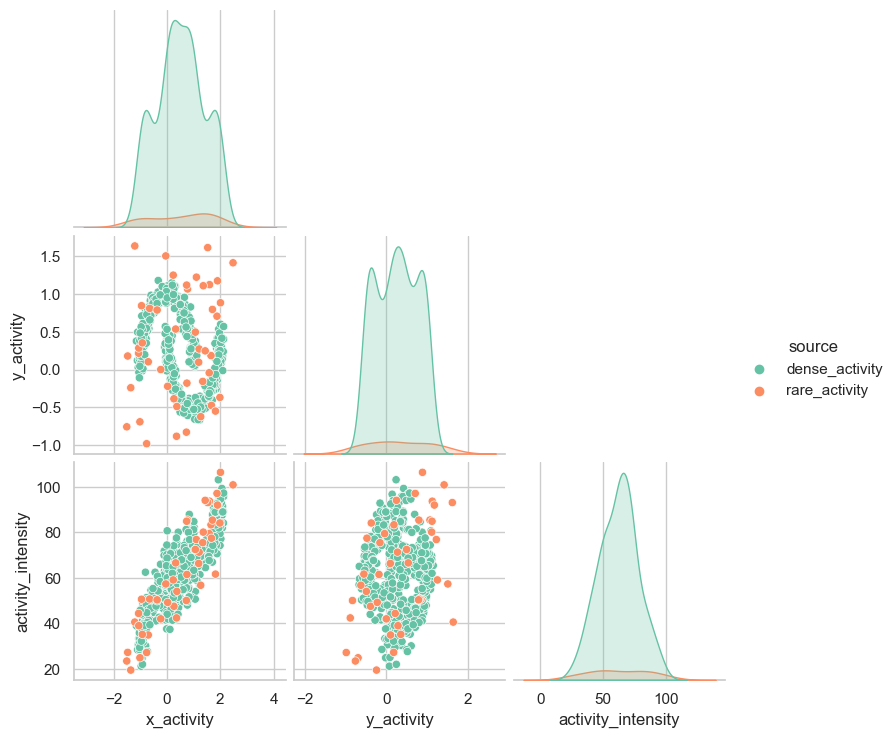

In [7]:
sns.pairplot(df[["x_activity", "y_activity", "activity_intensity", "source"]], hue="source", corner=True)
plt.savefig(IMAGES_DIR / "pairplot.png", dpi=160, bbox_inches="tight")
plt.show()

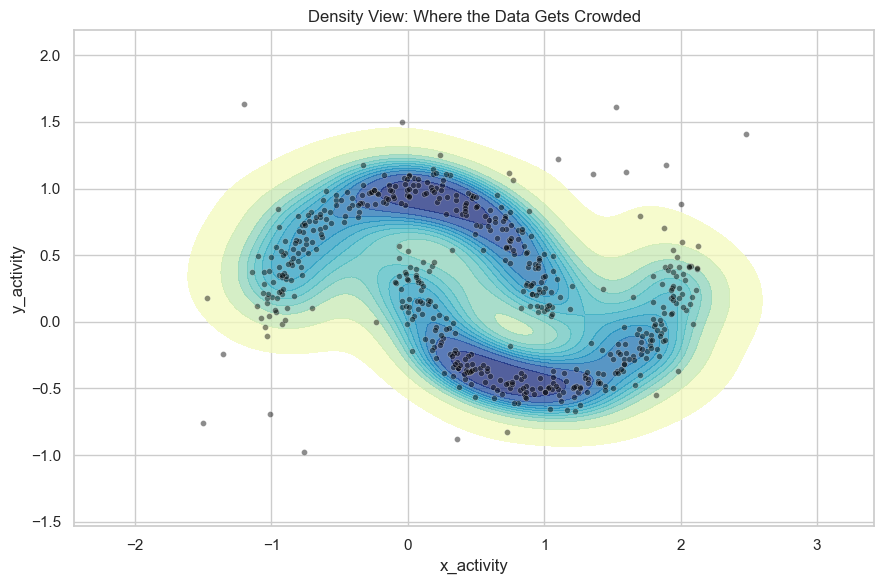

In [8]:
plt.figure(figsize=(9, 6))
sns.kdeplot(data=df, x="x_activity", y="y_activity", fill=True, levels=12, cmap="YlGnBu", alpha=0.75)
sns.scatterplot(data=df, x="x_activity", y="y_activity", color="black", s=18, alpha=0.45)
plt.title("Density View: Where the Data Gets Crowded")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "density_visualization.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Why Feature Scaling Matters

DBSCAN uses distance to decide neighborhoods.

If one feature is measured on a much larger scale, it can stretch the neighborhood and distort density. Scaling helps eps mean roughly the same thing across dimensions.

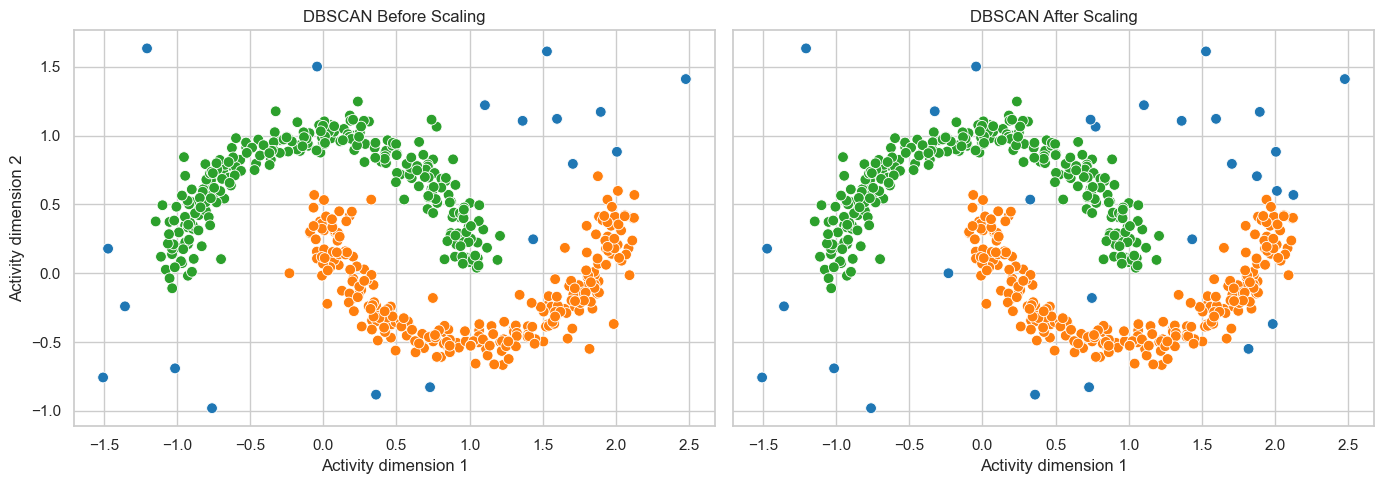

In [9]:
X_raw = df[FEATURE_COLUMNS].copy()
X_scaled, scaler = scale_features(df, FEATURE_COLUMNS)

_, raw_labels = fit_dbscan(X_raw, eps=0.22, min_samples=6)
_, scaled_labels = fit_dbscan(X_scaled, eps=0.22, min_samples=6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
sns.scatterplot(data=df.assign(cluster=raw_labels), x="x_activity", y="y_activity", hue="cluster", palette="tab10", s=60, ax=axes[0], legend=False)
axes[0].set_title("DBSCAN Before Scaling")
sns.scatterplot(data=df.assign(cluster=scaled_labels), x="x_activity", y="y_activity", hue="cluster", palette="tab10", s=60, ax=axes[1], legend=False)
axes[1].set_title("DBSCAN After Scaling")
for ax in axes:
    ax.set_xlabel("Activity dimension 1")
    ax.set_ylabel("Activity dimension 2")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "scaling_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Understanding DBSCAN Intuitively

DBSCAN has two main ideas:

- `eps`: how far a point can look around itself
- `min_samples`: how many neighbors it needs to feel like a dense place

A core point has enough neighbors inside its eps neighborhood.

A border point is near a core point but does not have enough neighbors itself.

A noise point is too isolated to belong to a dense community.

Imagine crowded cafes connected along a street. Core points are busy cafes. Border points are people near the crowd. Noise points are isolated houses far away.

In [10]:
final_eps = 0.22
final_min_samples = 6
dbscan_model, dbscan_labels = fit_dbscan(X_scaled, eps=final_eps, min_samples=final_min_samples)
labeled_df = attach_cluster_labels(df, dbscan_labels)
cluster_counts(dbscan_labels)

,cluster,points,cluster_type
0,-1,29,noise
1,0,256,cluster
2,1,260,cluster


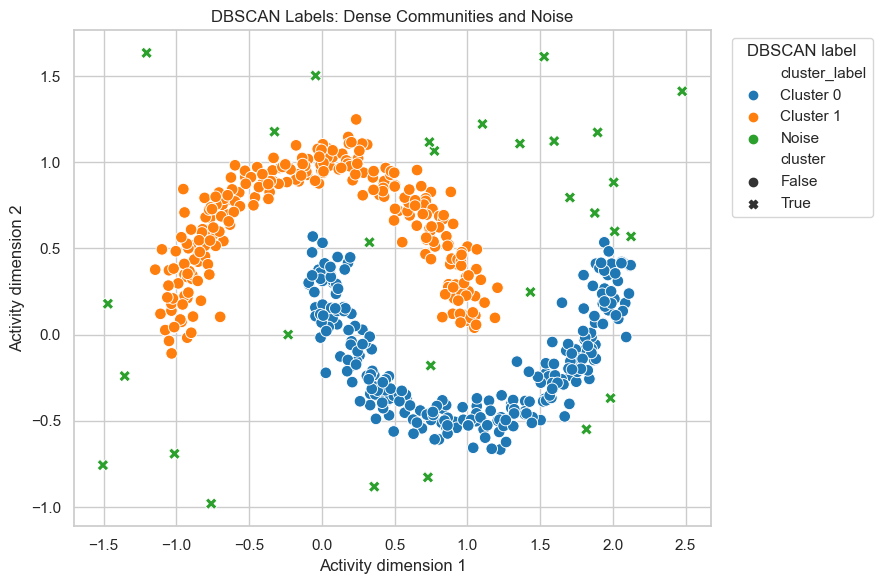

{'total_points': 545, 'noise_points': 29, 'noise_rate': 0.05321100917431193}

In [11]:
plot_cluster_scatter(df, dbscan_labels, IMAGES_DIR / "core_border_noise_points.png", title="DBSCAN Labels: Dense Communities and Noise")
plt.show()
noise_summary(df, dbscan_labels)

## 11. Choosing eps and min_samples

DBSCAN is powerful, but parameter-sensitive.

If eps is too small, neighborhoods are tiny and many points become noise.

If eps is too large, separate communities may melt into one giant cluster.

The k-distance graph helps us look for a bend where neighbor distances begin rising sharply.

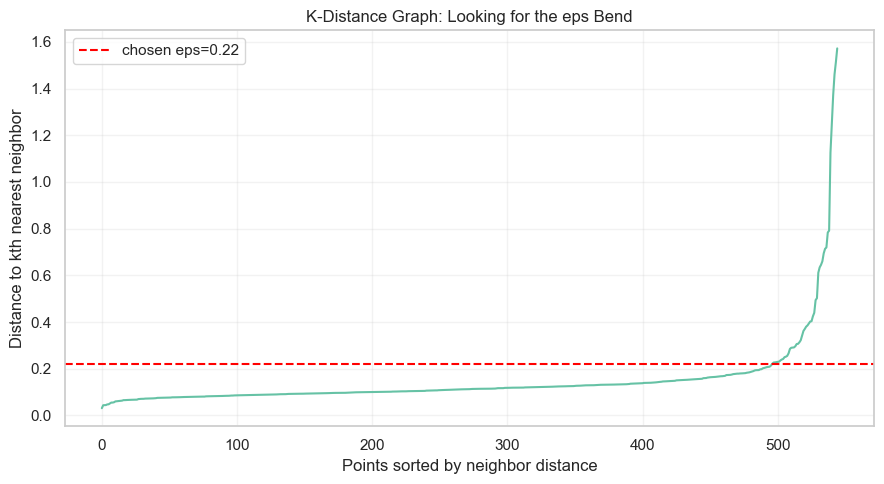

In [12]:
distances = k_distance_values(X_scaled, k=final_min_samples)
plot_k_distance(distances, IMAGES_DIR / "k_distance_graph.png")
plt.axhline(final_eps, color="red", linestyle="--", label=f"chosen eps={final_eps}")
plt.legend()
plt.show()

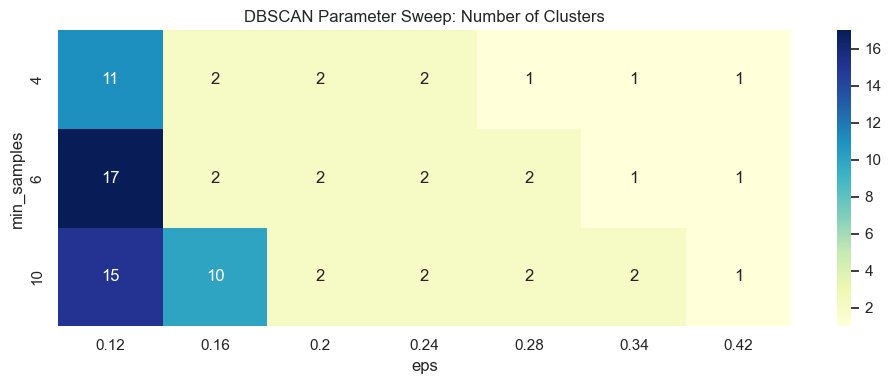

,eps,min_samples,clusters,noise_rate,silhouette_score
0,0.12,4,11,0.1211,0.1656
1,0.16,4,2,0.0752,0.3871
2,0.20,4,2,0.0587,0.3830
3,0.24,4,2,0.0440,0.3800
4,0.28,4,1,0.0349,NaN
5,0.34,4,1,0.0312,NaN
6,0.42,4,1,0.0257,NaN
7,0.12,6,17,0.1798,0.4496
8,0.16,6,2,0.0826,0.3879
9,0.20,6,2,0.0606,0.3858


In [13]:
sweep_df = run_parameter_sweep(X_scaled)
plot_parameter_heatmap(sweep_df, IMAGES_DIR / "parameter_sweep.png")
plt.show()
sweep_df.round(4).head(10)

## 12. Build DBSCAN Model

Now we train the final DBSCAN model using the selected eps and min_samples values.

In [14]:
print("eps:", final_eps)
print("min_samples:", final_min_samples)
print("clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("noise points:", int((dbscan_labels == -1).sum()))
print("noise rate:", round((dbscan_labels == -1).mean(), 4))

eps: 0.22
min_samples: 6
clusters: 2
noise points: 29
noise rate: 0.0532


## 13. Visualizing Clusters

This is where DBSCAN becomes visual.

It follows the curved dense communities instead of slicing them into round partitions. It also refuses to force isolated points into clusters.

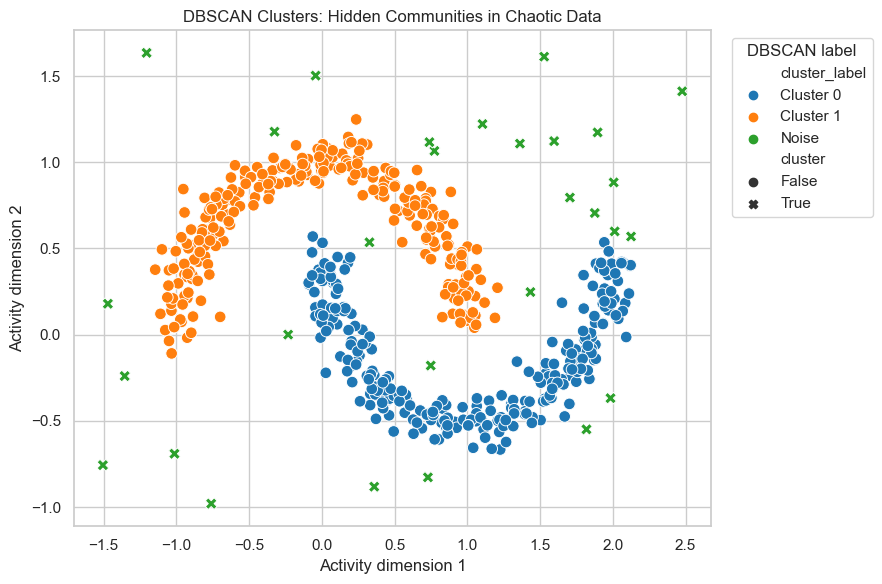

In [15]:
plot_cluster_scatter(df, dbscan_labels, IMAGES_DIR / "dbscan_clusters.png", title="DBSCAN Clusters: Hidden Communities in Chaotic Data")
plt.show()

## 14. Understanding Noise and Outliers

Noise is not failure.

Noise is DBSCAN saying: this point does not live in a dense neighborhood.

That is valuable. In fraud detection, rare behavior matters. In network security, isolated strange activity matters. In customer analytics, unusual activity may reveal edge cases, bots, abuse, or VIP behavior.

In [16]:
noise_points = labeled_df[labeled_df["cluster"] == -1]
noise_points.head()

,customer_event_id,x_activity,y_activity,activity_intensity,source,reference_pattern,cluster,point_type
134,EVT-0135,-0.325279,1.177191,59.33,dense_activity,0,-1,noise
458,EVT-0459,2.012740,0.598717,94.63,dense_activity,1,-1,noise
491,EVT-0492,2.125421,0.569220,97.27,dense_activity,1,-1,noise
501,EVT-0502,2.006111,0.882894,106.37,rare_activity,-1,-1,noise
502,EVT-0503,-1.204455,1.634180,40.60,rare_activity,-1,-1,noise


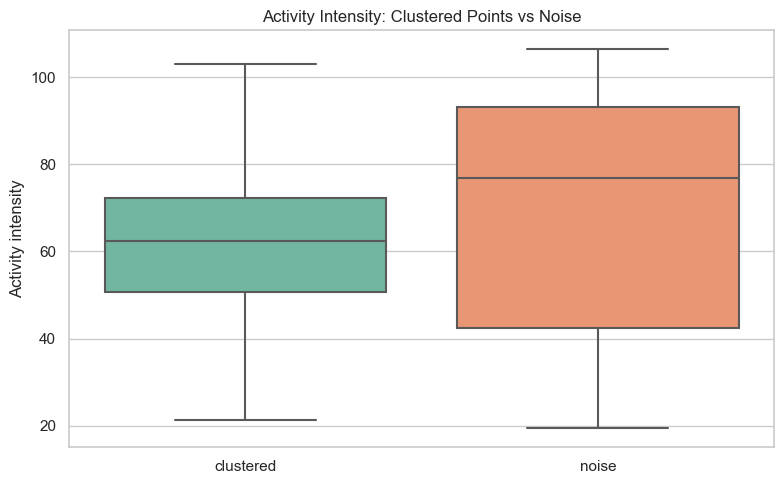

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=labeled_df, x="point_type", y="activity_intensity", palette="Set2")
plt.title("Activity Intensity: Clustered Points vs Noise")
plt.xlabel("")
plt.ylabel("Activity intensity")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "noise_activity_profile.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Comparing DBSCAN vs KMeans

KMeans wants every point assigned. DBSCAN allows some points to remain noise.

KMeans likes round clusters. DBSCAN can follow irregular shapes.

KMeans needs K upfront. DBSCAN discovers the number of dense regions from eps and min_samples.

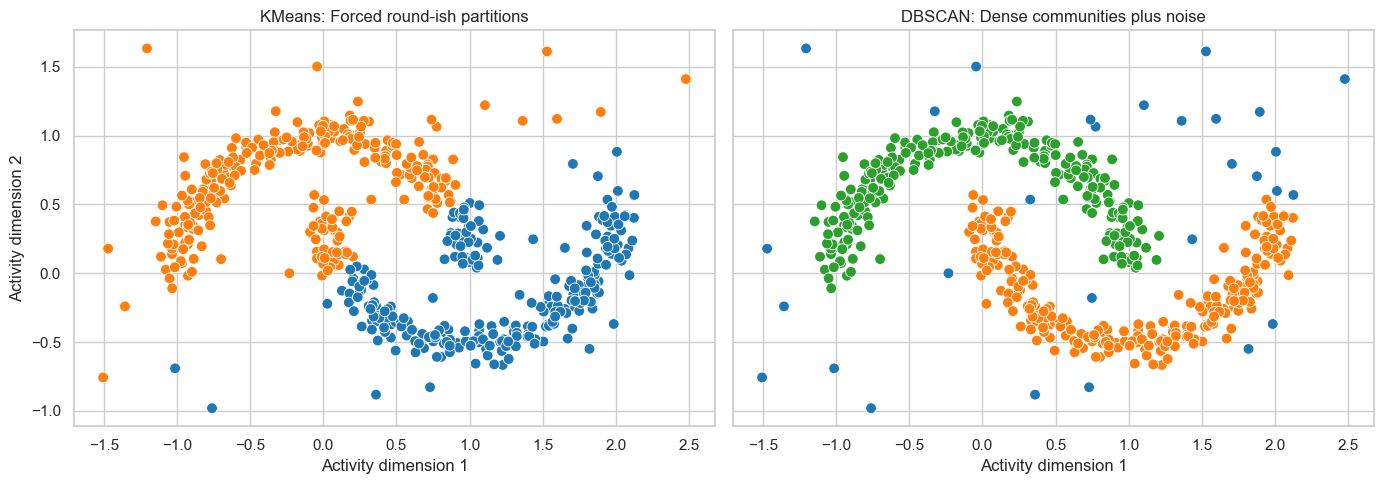

In [18]:
_, kmeans_labels = fit_kmeans(X_scaled, n_clusters=2)
plot_kmeans_vs_dbscan(df, kmeans_labels, dbscan_labels, IMAGES_DIR / "kmeans_vs_dbscan.png")
plt.show()

## 16. Evaluating Clustering Quality

Unsupervised learning has no perfect score because there is no true label.

Silhouette score can help, but DBSCAN includes noise, so we often evaluate only clustered points and combine the score with visual inspection and business meaning.

In [19]:
cluster_mask = dbscan_labels != -1
sil_score = silhouette_score(X_scaled[cluster_mask], dbscan_labels[cluster_mask])
print("Silhouette score on clustered points:", round(sil_score, 4))
print("Noise rate:", round((dbscan_labels == -1).mean(), 4))

Silhouette score on clustered points: 0.3831
Noise rate: 0.0532


## 17. Dimensionality Reduction for Visualization

PCA compresses features into two dimensions for visualization.

Here our main clustering space is already two-dimensional, but PCA is included as a practical pattern for larger DBSCAN workflows.

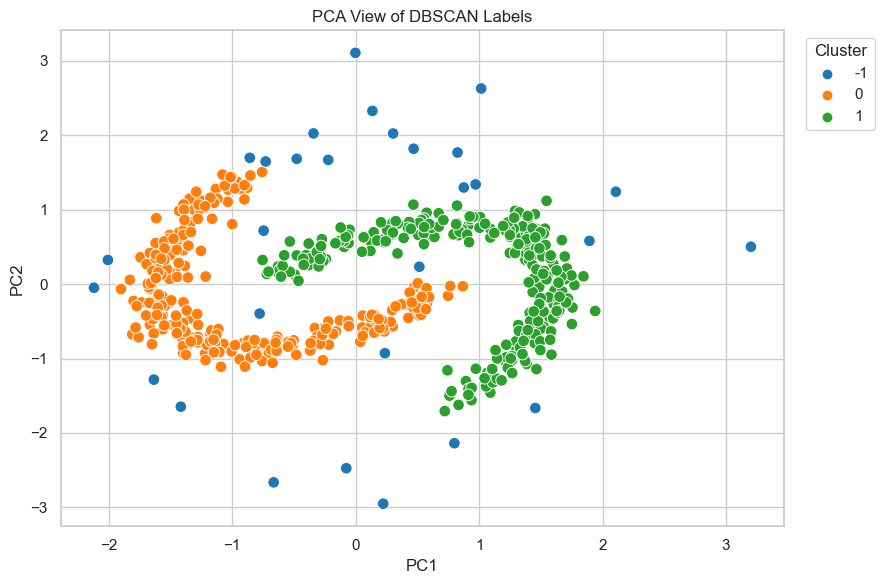

Explained variance: [0.674 0.326]


In [20]:
pca_df, pca = run_pca(X_scaled, n_components=2)
plot_pca_clusters(pca_df, dbscan_labels, IMAGES_DIR / "pca_clusters.png")
plt.show()
print("Explained variance:", np.round(pca.explained_variance_ratio_, 4))

## 18. Real-World Applications

DBSCAN is useful when dense regions and outliers matter:

- fraud detection
- geospatial hotspot discovery
- network intrusion detection
- healthcare anomaly discovery
- customer behavior analysis
- mobility and location clustering

It is especially useful when clusters are not neat circles.

## 19. Limitations of DBSCAN

DBSCAN is not magic.

It is sensitive to eps and min_samples. It can struggle when clusters have very different densities. It becomes harder in high-dimensional spaces where distance becomes less meaningful. It may not scale perfectly for very large datasets without optimized implementations.

The key is to use DBSCAN when density is the right story.

## 20. Final Takeaway

DBSCAN feels different because it does not force every point into a group.

It lets dense communities emerge naturally, and it leaves isolated points alone.

That is why it is so useful for messy real-world data: sometimes the most important signal is not only where the clusters are, but which points do not belong.

## 21. Interview Questions

For detailed interview preparation, see:

`dbscan/interview_questions.md`

The companion interview article explains these concepts in practical ML engineering language.